# Final Project: [ชื่อโครงงาน]
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: นาย ธนวรรธ ทองตื้อ (68114540258)
- สมาชิกที่ 2: ชื่อ-นามสกุล (รหัส)

**Dataset:** (https://www.kaggle.com/datasets/sergionefedov/college-major-roi)

**Problem Statement:** [อธิบาย 2-3 ประโยคว่าปัญหาคืออะไร ทำไมถึงสนใจ dataset นี้]

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ✅ |
| CLO2 (Statistical Learning) | Part 3 | ⬜ |
| CLO3 (Regression/Classification) | Part 4 | ⬜ |
| CLO4 (Model Selection) | Part 5 | ⬜ |

In [1]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [2]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์
from sys import displayhook

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
df = pd.read_csv('college_major_roi.csv')

columns_to_drop = [
    'grad_id', 'net_roi_usd', 'added_earnings_10yr_usd', 
    'hs_baseline_10yr_usd', 'roi_pct', 'positive_roi', 'high_roi', "major", "institution_tier"
]
df_clean = df.drop(columns=columns_to_drop)

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df_clean.shape}')
print(f"\ntypes:\n{df_clean.dtypes}")
print(f'\nColumns: {df_clean.columns.tolist()}')
print(f'\nMissing values:\n{df_clean.isnull().sum()}')
print(f'\nStats:')

df_only_number = df_clean[["institution_selectivity_pctile", "gpa", "net_cost_usd", "debt_usd", "earnings_10yr_usd"]]
display(df_only_number.describe())
df_clean.head()

Shape: (30000, 9)

types:
major_category                        str
institution_selectivity_pctile      int64
gpa                               float64
had_internship                      int64
completed_on_time                   int64
region                                str
net_cost_usd                        int64
debt_usd                            int64
earnings_10yr_usd                   int64
dtype: object

Columns: ['major_category', 'institution_selectivity_pctile', 'gpa', 'had_internship', 'completed_on_time', 'region', 'net_cost_usd', 'debt_usd', 'earnings_10yr_usd']

Missing values:
major_category                    0
institution_selectivity_pctile    0
gpa                               0
had_internship                    0
completed_on_time                 0
region                            0
net_cost_usd                      0
debt_usd                          0
earnings_10yr_usd                 0
dtype: int64

Stats:


,institution_selectivity_pctile,gpa,net_cost_usd,debt_usd,earnings_10yr_usd
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04
mean,55.086067,3.093337,88621.496667,38498.063333,7.153680e+05
std,18.593708,0.439060,33576.903160,37801.748200,2.977847e+05
min,16.000000,1.500000,28500.000000,0.000000,2.723000e+05
25%,42.000000,2.790000,65500.000000,0.000000,4.835000e+05
50%,55.000000,3.100000,81000.000000,38700.000000,6.458000e+05
75%,68.000000,3.400000,103600.000000,62300.000000,8.717000e+05
max,102.000000,4.000000,352900.000000,331700.000000,3.245500e+06


,major_category,institution_selectivity_pctile,gpa,had_internship,completed_on_time,region,net_cost_usd,debt_usd,earnings_10yr_usd
0,STEM,52,2.58,0,0,south,144400,0,512700
1,business,61,2.58,0,1,northeast,57400,0,687500
2,STEM,78,3.14,1,1,northeast,65100,39600,994700
3,business,77,3.04,0,1,midwest,105800,81300,597100
4,business,100,3.81,0,0,south,219200,93500,558600


In [3]:
def inspect_categorical_columns(dataframe, columns=None):
    if columns is None:
        columns = dataframe.select_dtypes(include=['object', 'category']).columns.tolist()
    
    for col in columns:
        unique_vals = dataframe[col].unique()
        n_unique = dataframe[col].nunique()
        
        print(f"\nคอลัมน์: '{col}'")
        print(f"ค่าที่มี: {list(unique_vals)}")
        
        print(" จำนวนข้อมูลในแต่ละกลุ่ม:")
        counts = dataframe[col].value_counts()
        for val, count in counts.items():
            pct = (count / len(dataframe)) * 100
            print(f"   - {val:<25} : {count:>5} คน ({pct:.2f}%)")
        print("-" * 50)

cat_cols = ['major_category', 'region']
inspect_categorical_columns(df_clean, columns=cat_cols)



คอลัมน์: 'major_category'
ค่าที่มี: ['STEM', 'business', 'social_science', 'education', 'health', 'arts', 'humanities']
 จำนวนข้อมูลในแต่ละกลุ่ม:
   - STEM                      :  9904 คน (33.01%)
   - business                  :  8361 คน (27.87%)
   - social_science            :  5989 คน (19.96%)
   - health                    :  1589 คน (5.30%)
   - humanities                :  1410 คน (4.70%)
   - arts                      :  1395 คน (4.65%)
   - education                 :  1352 คน (4.51%)
--------------------------------------------------

คอลัมน์: 'region'
ค่าที่มี: ['south', 'northeast', 'midwest', 'west']
 จำนวนข้อมูลในแต่ละกลุ่ม:
   - south                     :  9488 คน (31.63%)
   - northeast                 :  7512 คน (25.04%)
   - midwest                   :  6655 คน (22.18%)
   - west                      :  6345 คน (21.15%)
--------------------------------------------------


In [4]:
# ทดลองตรวจสอบสภาวะ multicollinearity ระหว่าง institution_tier กับ institution selectivity_pctile
new_df = pd.read_csv('college_major_roi.csv')

tier_summary = new_df.groupby('institution_tier')['institution_selectivity_pctile'].agg(['min', 'mean', 'max'])
print("📊 ช่วงคะแนนความยากในการสอบเข้าของแต่ละระดับมหาวิทยาลัย:")
display(tier_summary)

# แปลง Tier เป็นลำดับตัวเลขชั่วคราวเพื่อหาค่า Correlation
tier_map = {'for_profit': 0, 'regional': 1, 'mid_tier': 2, 'top_public': 3, 'ivy_elite': 4}
tier_numeric = new_df['institution_tier'].map(tier_map)

# คำนวณค่าสหสัมพันธ์ (Pearson Correlation)
corr_value = tier_numeric.corr(new_df['institution_selectivity_pctile'])
print(f"\n🔍 ค่า Correlation ระหว่าง Tier กับ Selectivity Pctile = {corr_value:.4f}")

📊 ช่วงคะแนนความยากในการสอบเข้าของแต่ละระดับมหาวิทยาลัย:


,min,mean,max
institution_tier,,,
for_profit,16,21.934901,28
ivy_elite,90,96.105023,102
mid_tier,52,58.035192,64
regional,36,42.036203,48
top_public,68,73.995330,80



🔍 ค่า Correlation ระหว่าง Tier กับ Selectivity Pctile = 0.9768


ผลการวิเคราะห์: ค่า correlation สูงถึง ~0.98 (เกือบ 1.0) แสดงถึงภาวะ Multicollinearity รุนแรง
ข้อสรุป: เราจึงตัด 'institution_tier' ออก และเก็บ 'institution_selectivity_pctile' ไว้เพียงตัวเดียว

In [5]:
# ทำ One-Hot Encoding สำหรับ major_category และ region เพื่อแปลงข้อความให้เป็นตัวเลข (0 1) เพื่อให้โมเดล Regression คำนวณได้
df_encoded_for_graph = pd.get_dummies(df_clean, columns=['major_category', 'region'], drop_first=False, dtype=int)
df_encoded = pd.get_dummies(df_clean, columns=['major_category', 'region'], drop_first=True, dtype=int)
display(df_encoded.head())


,institution_selectivity_pctile,gpa,had_internship,completed_on_time,net_cost_usd,debt_usd,earnings_10yr_usd,major_category_arts,major_category_business,major_category_education,major_category_health,major_category_humanities,major_category_social_science,region_northeast,region_south,region_west
0,52,2.58,0,0,144400,0,512700,0,0,0,0,0,0,0,1,0
1,61,2.58,0,1,57400,0,687500,0,1,0,0,0,0,1,0,0
2,78,3.14,1,1,65100,39600,994700,0,0,0,0,0,0,1,0,0
3,77,3.04,0,1,105800,81300,597100,0,1,0,0,0,0,0,0,0
4,100,3.81,0,0,219200,93500,558600,0,1,0,0,0,0,0,1,0


In [6]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
df_only_number.describe()

,institution_selectivity_pctile,gpa,net_cost_usd,debt_usd,earnings_10yr_usd
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04
mean,55.086067,3.093337,88621.496667,38498.063333,7.153680e+05
std,18.593708,0.439060,33576.903160,37801.748200,2.977847e+05
min,16.000000,1.500000,28500.000000,0.000000,2.723000e+05
25%,42.000000,2.790000,65500.000000,0.000000,4.835000e+05
50%,55.000000,3.100000,81000.000000,38700.000000,6.458000e+05
75%,68.000000,3.400000,103600.000000,62300.000000,8.717000e+05
max,102.000000,4.000000,352900.000000,331700.000000,3.245500e+06


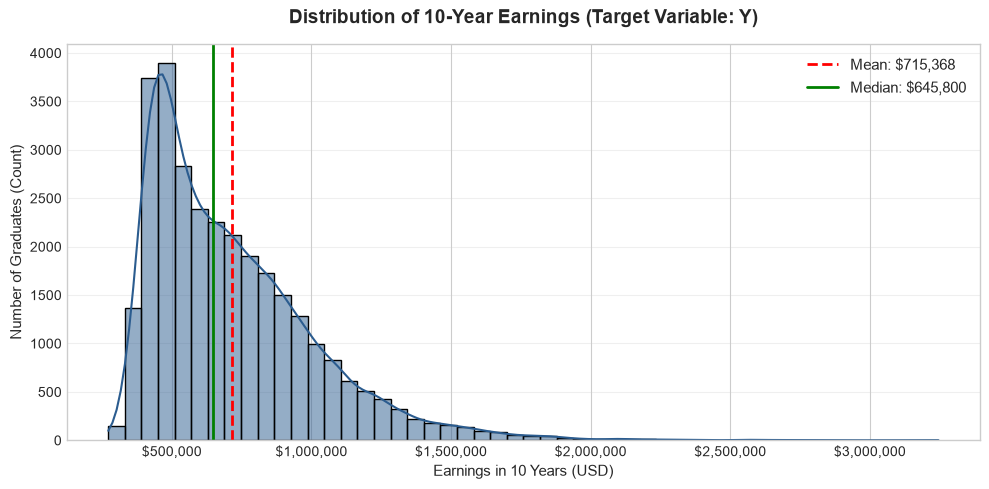

In [7]:
plt.figure(figsize=(10, 5))

# พล็อต Histogram และเส้น KDE
sns.histplot(df_clean['earnings_10yr_usd'], kde=True, bins=50, color='#2b5c8f')

# คำนวณค่าเฉลี่ยและมัธยฐาน
mean_val = df_clean['earnings_10yr_usd'].mean()
median_val = df_clean['earnings_10yr_usd'].median()

# วาดเส้น Mean และ Median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:,.0f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: ${median_val:,.0f}')

# ตกแต่งกราฟ
plt.title('Distribution of 10-Year Earnings (Target Variable: Y)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Earnings in 10 Years (USD)', fontsize=11)
plt.ylabel('Number of Graduates (Count)', fontsize=11)

# ปรับแกน X ให้อ่านเป็นหลักพัน/หลักล้านง่ายๆ (ใส่เครื่องหมาย comma)
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

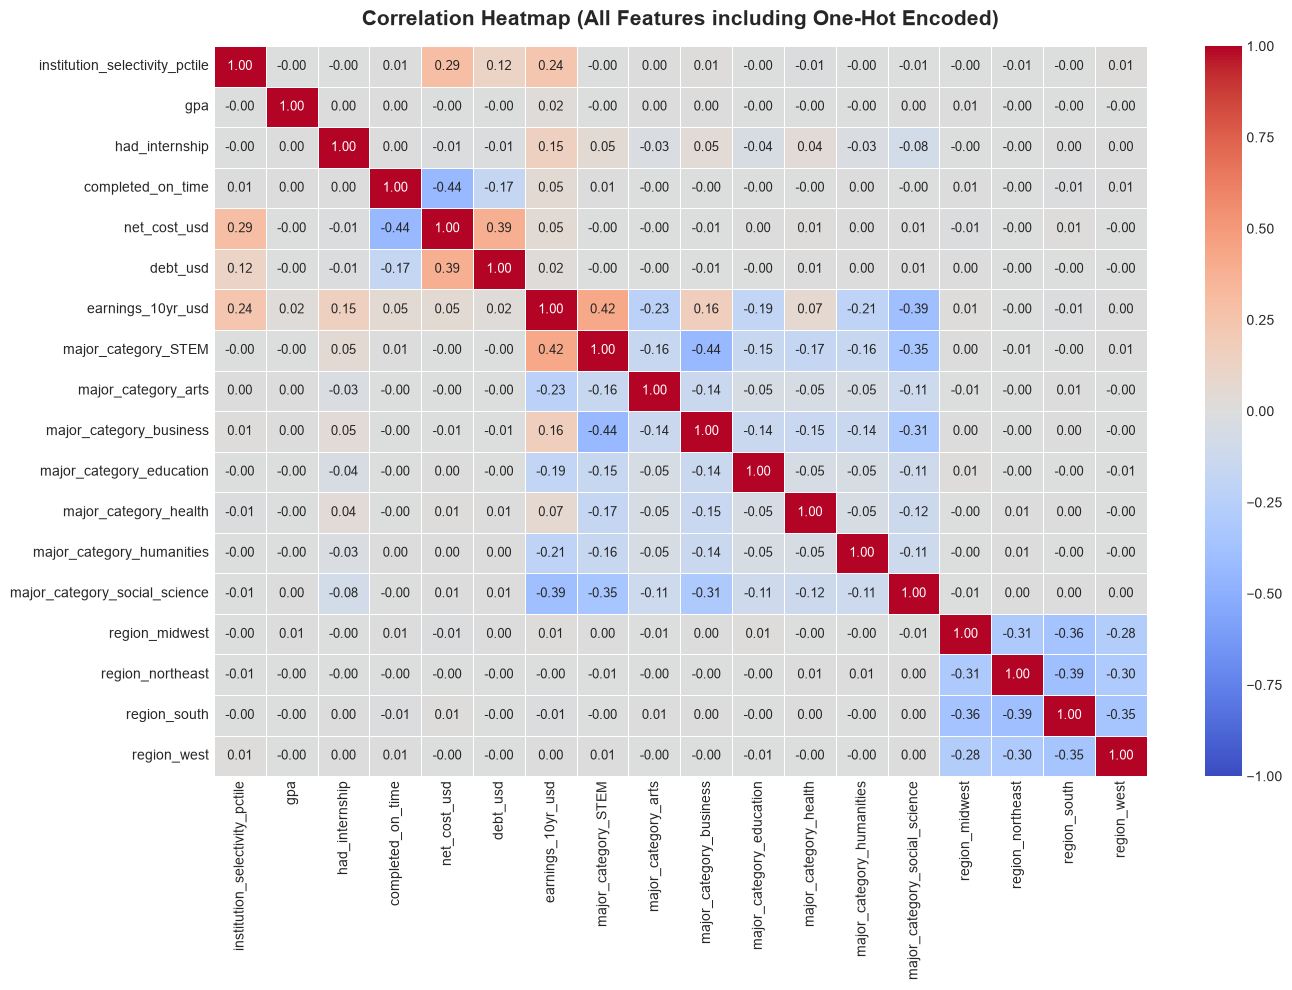

In [8]:
plt.figure(figsize=(14, 10))

# คำนวณ Correlation ของทุกคอลัมน์ใน df_encoded
corr_matrix_all = df_encoded_for_graph.corr()

# พล็อต Heatmap ทั้งหมด
sns.heatmap(
    corr_matrix_all, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    linewidths=0.5,
    annot_kws={"size": 9} # ปรับขนาดตัวเลขข้างในให้พอดี
)

plt.title('Correlation Heatmap (All Features including One-Hot Encoded)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** กลุ่มเราเลือก **Task A (PCA)** เพราะ PCA ครอบคลุมแก่นของ Task C (Covariance/Correlation Analysis) อยู่ในตัวเองอยู่แล้ว — หัวใจของ PCA คือการทำ eigendecomposition ของ covariance matrix ซึ่งเป็น Linear Algebra ล้วน ๆ และเหมาะกับข้อมูลของเราที่หลัง one-hot encoding แล้วมี features ถึง 15 ตัว โดยแต่ละตัวมี scale ต่างกันมาก (ค่าเทอมหลักหมื่น vs เกรด 0-4 vs dummy 0/1) เราจึงอยากตอบคำถามว่าข้อมูลมีโครงสร้างซ้ำซ้อนมากพอที่จะบีบลงเหลือไม่กี่มิติได้หรือไม่ และแต่ละ Principal Component สะท้อนปัจจัยด้านใดของบัณฑิต — Insight ที่คาดว่าจะได้คือจำนวน component ขั้นต่ำที่รักษา variance เดิมไว้ได้ และว่าทิศทางที่ variance สูงที่สุดใช้ทำนายรายได้ได้จริงหรือไม่

ขนาด Feature Matrix X: 30,000 แถว (บัณฑิต) x 15 คอลัมน์ (features)


,PC,Eigenvalue,Explained Variance (%),Cumulative (%)
0,PC1,1.757,11.714,11.714
1,PC2,1.404,9.359,21.072
2,PC3,1.342,8.944,30.016
3,PC4,1.295,8.633,38.649
4,PC5,1.130,7.531,46.180
5,PC6,1.086,7.239,53.419
6,PC7,1.049,6.995,60.414
7,PC8,1.049,6.993,67.408
8,PC9,1.005,6.702,74.110
9,PC10,0.999,6.660,80.769


ต้องใช้ 10 จาก 15 components เพื่อเก็บ variance ไว้ได้ 80%
ต้องใช้ 12 จาก 15 components เพื่อเก็บ variance ไว้ได้ 90%


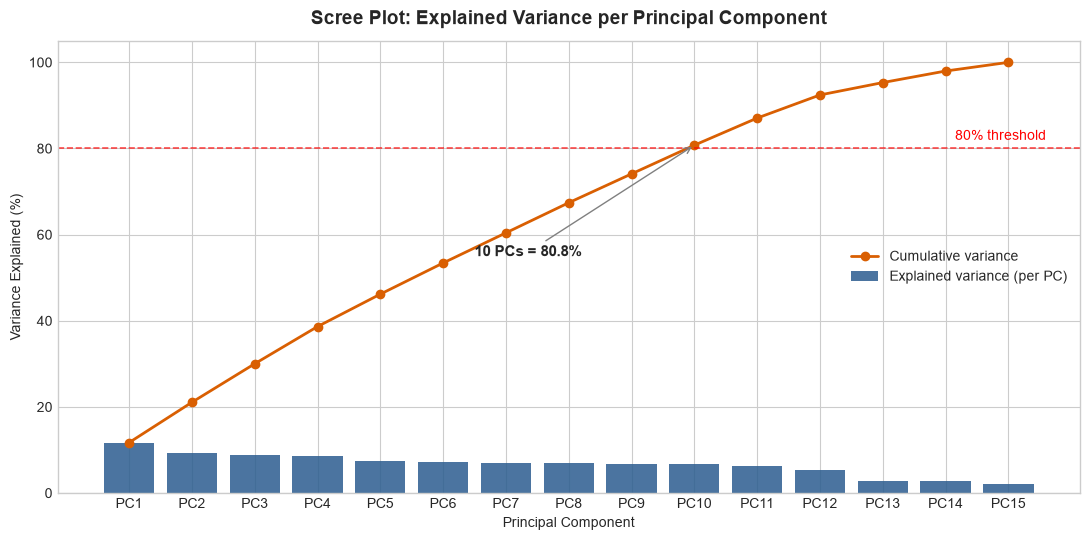

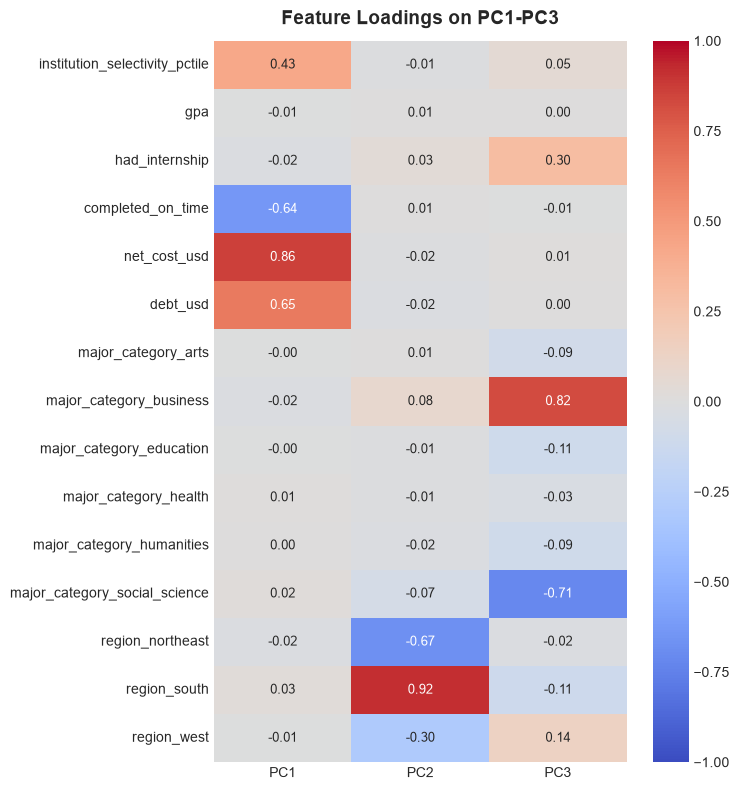

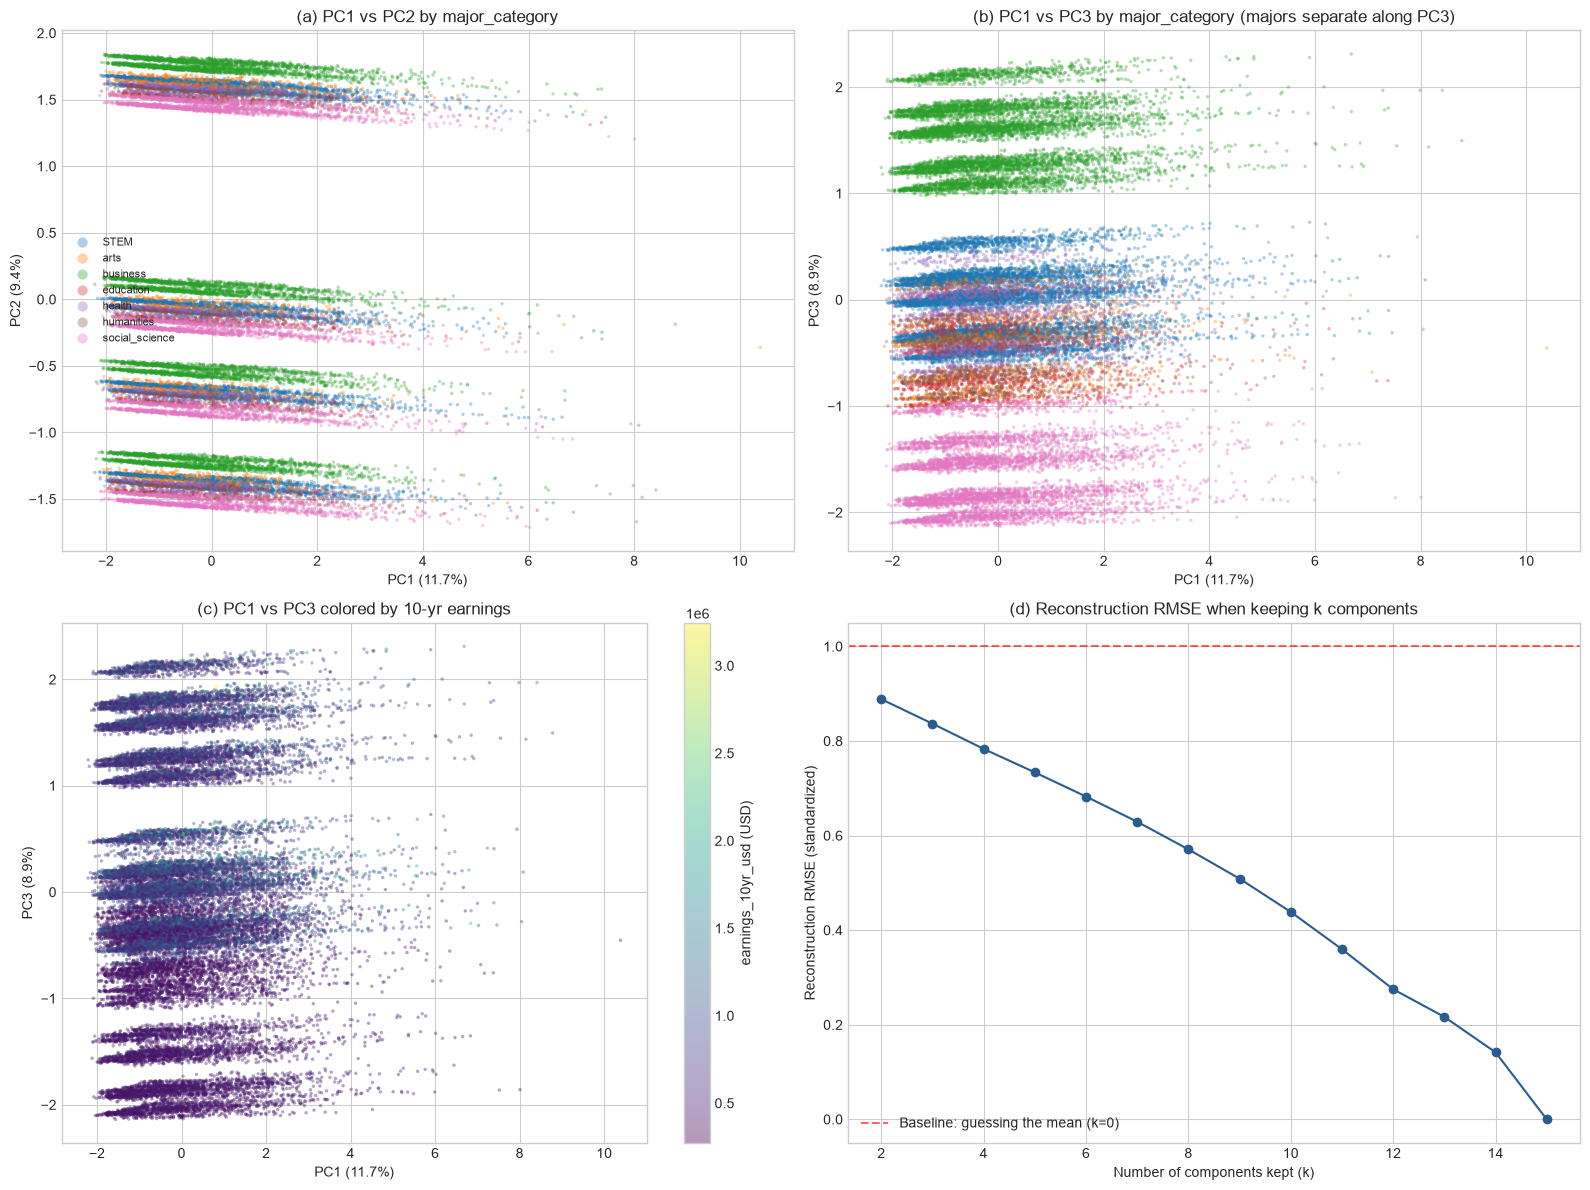

Correlation ระหว่าง PC แต่ละตัวกับรายได้ 10 ปี (8 ตัวแรก):


,corr with earnings_10yr_usd
PC1,0.065
PC2,0.029
PC3,0.400
PC4,-0.035
PC5,0.025
PC6,0.195
PC7,-0.019
PC8,-0.033


In [9]:
# ─── CLO1: Linear Algebra Analysis (Task A: PCA) ─────────────────
# วัตถุประสงค์: ทำ PCA ด้วย Linear Algebra ล้วน ๆ คือสร้าง Covariance Matrix
# และทำ Eigendecomposition ด้วย numpy เอง (ไม่เรียกใช้ sklearn.decomposition.PCA)
# เพื่อลด dimension ของ features และดูว่าโครงสร้างของข้อมูลซ่อนอยู่ตรงไหน

# ── Step 1: สร้าง Feature Matrix X (ตัด target ออกเพื่อป้องกัน Data Leakage) ──
target_col = 'earnings_10yr_usd'
feature_cols = [c for c in df_encoded.columns if c != target_col]
X = df_encoded[feature_cols].values.astype(float)
print(f'ขนาด Feature Matrix X: {X.shape[0]:,} แถว (บัณฑิต) x {X.shape[1]} คอลัมน์ (features)')

# ── Step 2: Standardize ข้อมูลให้มี mean = 0, std = 1 ──
# จำเป็นต้องทำเพราะ scale ของแต่ละ feature ต่างกันมาก (net_cost_usd เป็นหลักหมื่น
# แต่ gpa อยู่แค่ 0-4 และ dummy เป็น 0/1) ถ้าไม่ standardize ทิศทางที่ variance สูงสุด
# จะถูก feature ที่มีตัวเลขใหญ่ที่สุด (ค่าเทอม) ชิงไปทั้งแกน
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

# ── Step 3: สร้าง Covariance Matrix แล้วทำ Eigendecomposition ──
# C = (1/(n-1)) * X_scaled.T @ X_scaled  →  C เป็น symmetric matrix เสมอ
n_samples = X_scaled.shape[0]
cov_matrix = (1 / (n_samples - 1)) * X_scaled.T @ X_scaled

# np.linalg.eigh ออกแบบมาสำหรับ symmetric matrix โดยเฉพาะ (เร็วกว่า eig ทั่วไป)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# เรียง eigenvalues/eigenvectors จากมากไปน้อย (PC1 คือทิศทางที่ variance สูงสุด)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# เครื่องหมายของ eigenvector เป็น v หรือ -v ก็ถือเป็นแกนเดียวกัน
# เราจึง fix ให้ feature ที่มี |loading| สูงสุดของแต่ละ PC เป็นบวกเสมอ
# เพื่อให้ผลตีความได้เหมือนกันทุกครั้งที่รัน
for j in range(eigenvectors.shape[1]):
    pivot = np.argmax(np.abs(eigenvectors[:, j]))
    if eigenvectors[pivot, j] < 0:
        eigenvectors[:, j] = -eigenvectors[:, j]

explained_ratio = eigenvalues / eigenvalues.sum()
cumulative_ratio = np.cumsum(explained_ratio)

# ── Step 4: สรุป variance ที่แต่ละ PC เก็บได้ ──
variance_table = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues,
    'Explained Variance (%)': explained_ratio * 100,
    'Cumulative (%)': cumulative_ratio * 100,
}).round(3)
display(variance_table.head(10))

n_80 = int(np.argmax(cumulative_ratio >= 0.80) + 1)
n_90 = int(np.argmax(cumulative_ratio >= 0.90) + 1)
print(f'ต้องใช้ {n_80} จาก {len(eigenvalues)} components เพื่อเก็บ variance ไว้ได้ 80%')
print(f'ต้องใช้ {n_90} จาก {len(eigenvalues)} components เพื่อเก็บ variance ไว้ได้ 90%')

# ── Step 5: Scree Plot ──
fig, ax = plt.subplots(figsize=(11, 5.5))
pc_labels = [f'PC{i+1}' for i in range(len(eigenvalues))]
ax.bar(pc_labels, explained_ratio * 100, color='#2b5c8f', alpha=0.85, label='Explained variance (per PC)')
ax.plot(pc_labels, cumulative_ratio * 100, color='#d95f02', marker='o', linewidth=2, label='Cumulative variance')
ax.axhline(80, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(len(eigenvalues) - 0.4, 82, '80% threshold', color='red', ha='right', fontsize=10)
ax.annotate(f'{n_80} PCs = {cumulative_ratio[n_80-1]*100:.1f}%',
            xy=(n_80 - 1, cumulative_ratio[n_80-1] * 100),
            xytext=(n_80 - 4.5, 55),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=11, fontweight='bold')
ax.set_title('Scree Plot: Explained Variance per Principal Component', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_ylim(0, 105)
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

# ── Step 6: Loadings — ดูว่าแต่ละ PC ประกอบจาก features อะไรบ้าง ──
n_show = 3
loadings = eigenvectors[:, :n_show] * np.sqrt(eigenvalues[:n_show])
loadings_df = pd.DataFrame(loadings, index=feature_cols, columns=[f'PC{i+1}' for i in range(n_show)])

fig, ax = plt.subplots(figsize=(7.5, 8))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Loadings on PC1-PC3', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# ── Step 7: Project ข้อมูลลงระนาบ 2 มิติ (2D Visualization) ──
Z2 = X_scaled @ eigenvectors[:, :2]   # พิกัดใหม่บนระนาบ PC1-PC2
Z3 = X_scaled @ eigenvectors[:, 2]    # แกน PC3 เพิ่มเติม (เหตุผลดูจากผลลัพธ์ข้างล่าง)
pc_pct = explained_ratio * 100

major_labels = df_clean['major_category'].to_numpy()
unique_majors = sorted(df_clean['major_category'].unique())
palette = dict(zip(unique_majors, sns.color_palette('tab10', len(unique_majors))))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) 2 มิติแรกตามตำรา: PC1 vs PC2
ax = axes[0, 0]
for m in unique_majors:
    mask = major_labels == m
    ax.scatter(Z2[mask, 0], Z2[mask, 1], s=6, alpha=0.35, color=palette[m], label=m, edgecolors='none')
ax.set_title('(a) PC1 vs PC2 by major_category')
ax.set_xlabel(f'PC1 ({pc_pct[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({pc_pct[1]:.1f}%)')
ax.legend(fontsize=8, markerscale=3, loc='center left')

# (b) เปลี่ยนแกนที่สองเป็น PC3 — จะเห็นว่าสาขาแยกกันบนแกน PC3 ไม่ใช่ PC2
ax = axes[0, 1]
for m in unique_majors:
    mask = major_labels == m
    ax.scatter(Z2[mask, 0], Z3[mask], s=6, alpha=0.35, color=palette[m], label=m, edgecolors='none')
ax.set_title('(b) PC1 vs PC3 by major_category (majors separate along PC3)')
ax.set_xlabel(f'PC1 ({pc_pct[0]:.1f}%)')
ax.set_ylabel(f'PC3 ({pc_pct[2]:.1f}%)')

# (c) ระบายสีด้วยรายได้จริง — สัญญาณรายได้วิ่งตามแกน PC3
ax = axes[1, 0]
sc = ax.scatter(Z2[:, 0], Z3, s=6, alpha=0.4, c=df_encoded[target_col], cmap='viridis', edgecolors='none')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('earnings_10yr_usd (USD)')
ax.set_title('(c) PC1 vs PC3 colored by 10-yr earnings')
ax.set_xlabel(f'PC1 ({pc_pct[0]:.1f}%)')
ax.set_ylabel(f'PC3 ({pc_pct[2]:.1f}%)')

# (d) ราคาที่ต้องจ่ายเมื่อเก็บข้อมูลไว้แค่ k มิติ (Reconstruction Error)
ax = axes[1, 1]
ks = list(range(2, len(eigenvalues) + 1))
rmses = []
for k in ks:
    Zk = X_scaled @ eigenvectors[:, :k]
    X_approx = Zk @ eigenvectors[:, :k].T
    rmses.append(np.sqrt(((X_scaled - X_approx) ** 2).mean()))
ax.plot(ks, rmses, marker='o', color='#2b5c8f')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Baseline: guessing the mean (k=0)')
ax.set_title('(d) Reconstruction RMSE when keeping k components')
ax.set_xlabel('Number of components kept (k)')
ax.set_ylabel('Reconstruction RMSE (standardized)')
ax.legend()

plt.tight_layout()
plt.show()

# ── Step 8: สัญญาณของ target อยู่บน PC ไหนบ้าง ──
pc_target_corr = pd.Series(
    {f'PC{i+1}': np.corrcoef(X_scaled @ eigenvectors[:, i], df_encoded[target_col])[0, 1]
     for i in range(8)}
).round(3)
print('Correlation ระหว่าง PC แต่ละตัวกับรายได้ 10 ปี (8 ตัวแรก):')
display(pc_target_corr.to_frame('corr with earnings_10yr_usd'))

**Insight จาก CLO1 Analysis:**

**1. Variance กระจายเกือบเท่ากันทุกทิศทาง — การลดมิติทำได้จำกัด**
PC1 อธิบาย variance ได้เพียง ~11.7% และต้องใช้ถึง **10 จาก 15 components** จึงจะเก็บ variance ไว้ได้ 80% (12 components สำหรับ 90%) แปลว่า covariance matrix หลัง standardize มี eigenvalues ใกล้ 1 เกือบทุกแกน หรือก็คือ features ของเราแทบไม่มี correlation ระหว่างกันเลย การ reconstruct ข้อมูลจากเพียง 2 components จึงคลาดเคลื่อน RMSE ≈ 0.89 ในหน่วย standardized (เสียข้อมูลราว 79% — ดูเส้นกราฟ (d))

**2. สามแกนหลักของข้อมูลมีความหมายชัดเจน (จาก Loadings heatmap):**
- **PC1 (11.7%) = แกน "ต้นทุนการศึกษา"** — net_cost_usd (+0.86), debt_usd (+0.65) และ institution_selectivity_pctile (+0.43) วิ่งไปด้วยกัน แต่ completed_on_time โหลดสวนทาง (-0.64) สะท้อนว่าบัณฑิตที่เรียนในสถาบันที่แพงและคัดเลือกยากมักมีหนี้สูง และจบตามกำหนดเวลาน้อยลง (corr(net_cost, on_time) = -0.44)
- **PC2 (9.4%) = แกน "ภูมิภาค"** — region_south (+0.92) สวนทางกับ region_northeast (-0.67) และ region_west (-0.30)
- **PC3 (8.9%) = แกน "สาขาวิชา"** — business (+0.82) สวนทางกับ social_science (-0.71) โดย had_internship เอนไปทางฝั่ง business (+0.30)

**3. สัญญาณรายได้ไม่ได้อยู่บน PC ที่ variance สูงสุด (บทเรียนสำคัญของ PCA)**
corr(PC1, รายได้) ≈ 0.07 เกือบเป็นศูนย์ แต่ **PC3 ที่อธิบาย variance แค่ 8.9% กลับมี correlation กับรายได้ถึง +0.40** (ฝั่ง business มีรายได้สูงกว่า — เห็นไล่ระดับสีชัดในกราฟ (c)) และ PC6 ซึ่งเป็นแกน health + internship ก็มี corr ≈ +0.20 นี่คือหลักฐานว่า **PCA เลือกทิศทางที่ variance สูงสุด ซึ่งไม่จำเป็นต้องเป็นทิศทางที่ทำนาย target ได้ดีที่สุด** ดังนั้นหากนำ PCA มาลดมิติก่อนสร้างโมเดล การตัด PC ตัวท้าย ๆ ทิ้งเพียงเพราะ variance ต่ำ อาจทิ้งปัจจัยสำคัญที่สุดต่อรายได้ (สาขาวิชา) หายไปด้วย — ข้อสังเกตนี้จะนำไปพิจารณาต่อในการเลือก features ของ Part 3-4

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

In [10]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# TODO:
# 1. Plot distributions
# 2. Correlation analysis กับ target
# 3. แสดง U-curve ของ Train/Test MSE (polynomial degree หรือ model complexity)
pass

**Insight จาก CLO2 Analysis:**
> [อธิบาย: features สำคัญคืออะไร? distribution ของ target เป็นอย่างไร? optimal complexity อยู่ที่เท่าไหร่?]

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ⬜ Regression  ⬜ Classification

In [11]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 1 คืออะไร]

# TODO:
# X_train, X_test, y_train, y_test = train_test_split(...)
# model1 = ???
# model1.fit(X_train, y_train)
# ...
pass

In [12]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 2 คืออะไร]

# TODO:
# model2 = ???
# ...
pass

**สรุป Model Comparison:**

| Model | Train Metric | Test Metric | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: ___ | | | |
| Model 2: ___ | | | |

**Insight:**
> [เปรียบเทียบ: Model ไหนดีกว่า? ทำไม? มี overfitting/underfitting ไหม?]

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

In [13]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
# models = {
#     'Model 1': ???,
#     'Model 2': ???,
#     'Model 3': ???,
# }
#
# for name, model in models.items():
#     scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
#     cv_mse = -scores.mean()
#     print(f'{name}: CV MSE = {cv_mse:.4f}')
pass

**Best Model จาก Cross-Validation:** [ระบุ]

**เหตุผล:**
> [อธิบาย: CV MSE ต่ำสุดคือเท่าไหร่? มี overfitting ไหม? เชื่อมกับ Bias-Variance อย่างไร?]

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- CLO1: ...
- CLO2: ...
- CLO3: ...
- CLO4: ...

**6.2 Limitations:**
> [อะไรที่ทำไม่ได้หรือมีข้อจำกัด เช่น dataset เล็กเกินไป, missing values, features ไม่ครบ]

**6.3 ขั้นตอนต่อไป (Future Work):**
> [ถ้ามีเวลามากกว่านี้จะทำอะไรต่อ]

**6.4 Connection กับ Topics ในวิชา:**
> [เชื่อมกับ Week ต่างๆ ที่เรียนมา ว่า concept ไหนนำมาใช้จริงในโครงงานนี้]

---
**Acknowledgements:** [ขอบคุณแหล่งข้อมูล / tools / references ที่ใช้]